In [1]:
from miso.hist_features import get_features
from miso.utils import *
from miso import Miso
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)
import warnings
warnings.filterwarnings("ignore")
if torch.cuda.is_available():
    device = 'cuda:1'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")

CUDA is available. GPU: NVIDIA A800-SXM4-80GB


In [2]:
#If an H&E image is available, this code chunk extracts spot-level histology features
im = Image.open('/home/dbj/mouse/spatialglue_alldata/Dataset8_Mouse_Brain_H3K4me3/MouseBrain_20um_100barcodes_H3K4me3_spatial/tissue_hires_image.png')


#microns per pixel in H&E image
pixel_size_raw = 65/255.54640512302527

#desired microns per pixel
pixel_size = 1.0

#spot radius in pixels
rad=55/(2*pixel_size_raw)

#spot spatial locations
#column 1: binary indicator for whether spot is in tissue; column 2: row coordinate of spot in array; column 3: column coordinate of spot in array; column 4: row pixel coordinate of spot; column 5: column pixel coordinate of spot; 
locs=pd.read_csv('/home/dbj/mouse/spatialglue_alldata/Dataset8_Mouse_Brain_H3K4me3/MouseBrain_20um_100barcodes_H3K4me3_spatial/tissue_positions_list.csv',index_col=0)
locs.columns = [str(i) for i in range(1,6)]
image_emb = get_features(im,locs,rad,pixel_size_raw,pixel_size,pretrained=True,device=device)
np.save('image_emb.npy', image_emb)

Scaling image
Preprocessing image
Adjusting margins


Extracting image features: 1/4:   0%|          | 0/4 [00:00<?, ?it/s]

Extracting image features: 2/4:   0%|          | 0/4 [00:00<?, ?it/s]

Extracting image features: 3/4:   0%|          | 0/4 [00:00<?, ?it/s]

Extracting image features: 4/4:   0%|          | 0/4 [00:00<?, ?it/s]

Smoothing embeddings


In [3]:
file_fold = '/home/dbj/mouse/spatialglue_alldata/Dataset8_Mouse_Brain_H3K4me3/' #please replace 'file_fold' with the download path

adata1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata2 = sc.read_h5ad(file_fold + 'adata_peaks_normalized.h5ad')
adata1.var_names_make_unique()
adata2.var_names_make_unique()
sc.pp.filter_genes(adata1, min_cells=10)
sc.pp.filter_cells(adata1, min_genes=200)
sc.pp.highly_variable_genes(adata1, flavor="seurat_v3", n_top_genes=3000)
adata1 =  adata1[:, adata1.var['highly_variable']]
adata2 = adata2[adata1.obs_names].copy()
sc.pp.highly_variable_genes(adata2, flavor="seurat_v3", n_top_genes=3000)
adata2 =  adata2[:, adata2.var['highly_variable']]

In [4]:
column_names = ['barcode', 'in_tissue', 'x', 'y', 'pixel_x', 'pixel_y']  # 根据实际列名调整
spatial = pd.read_csv('/home/dbj/mouse/spatialglue_alldata/Dataset8_Mouse_Brain_H3K4me3/MouseBrain_20um_100barcodes_H3K4me3_spatial/tissue_positions_list.csv',index_col=0,header=None,names=column_names)

In [5]:
adata_omics1=adata1
adata_omics2=adata2

In [6]:
#rna=sc.read_h5ad('/home/dbj/mouse/spatialglue_alldata/Dataset8_Mouse_Brain_H3K4me3/adata_RNA.h5ad')
rna = preprocess(adata_omics1,modality='rna')
#atac=sc.read_h5ad('/home/dbj/mouse/spatialglue_alldata/Dataset8_Mouse_Brain_H3K4me3/adata_peaks_normalized.h5ad')
atac = preprocess(adata_omics2,modality='protein')

In [7]:
model = Miso([rna,atac],ind_views='all',combs='all',sparse=False,device=device)
model.train()
np.save('emb.npy', model.emb)

Training network for modality 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Training network for modality 2:   0%|          | 0/1000 [00:00<?, ?it/s]

In [8]:
clusters = model.cluster(n_clusters=18)

In [9]:
import pandas as pd

# Assuming 'clusters' is a list or array-like object containing the cluster assignments
adata_omics1.obs['MISO'] = pd.Categorical(clusters)

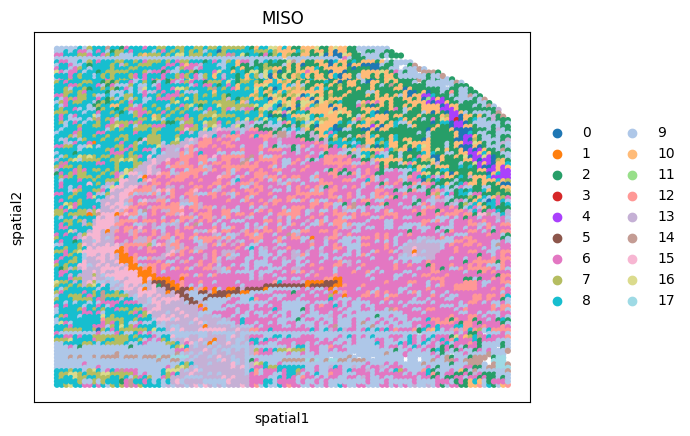

In [10]:
sc.pl.embedding(adata_omics1,basis='spatial',color='MISO',size=80)